In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import os
import re
import json
import numpy as np

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [142]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))

In [143]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df

In [144]:
# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:
def train(X_train, y_train, X_val, y_val):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
            'random_state': 42
        }
        
        # 创建模型
        model = RandomForestClassifier(**params)
        
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测验证集概率
        y_val_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # 计算 AUC
        auc_score = roc_auc_score(y_val, y_val_pred_proba)
        
        # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
        return 1.0 - auc_score

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = best_trial.params
    best_params['random_state'] = 42

    final_model = RandomForestClassifier(**best_params)
    final_model.fit(X_train, y_train)
     
    return [final_model,best_params]

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name):
    # y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # 最佳阈值
    best_thresh, best_auc = 0.5, 0
    for thresh in np.arange(0.1, 0.65, 0.05):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = roc_auc_score(y, pred_val)
        if f1 > best_auc:
            best_thresh, best_auc = thresh, f1

    print(f"最佳阈值: {best_thresh:.2f}，测试集最大auc: {best_auc:.4f}")

    y_pred = (y_pred_proba >= best_thresh).astype(int)
    
    # if dataset_name == '测试':
    #     predict = [[], []]
    #     y = list(y)
    #     for i in range(len(y)):
    #         if y[i] == 0:
    #             predict[0].append(y_pred_proba[i])
    #         if y[i] == 1:
    #             predict[1].append(y_pred_proba[i])

    #     plt.boxplot(predict)
    #     plt.xticks([1, 2], ['非阴性组', '阴性组'])
    #     plt.title(key)
    #     plt.ylabel("可能性")
    #     plt.show()

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)
    
    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    # res_pr = bootstrap_prauc_ci(y_true_test, y_score_test, B=1000, seed=2025)
    # print(f"PR-AUC = {res_pr['point']:.3f} "
    #     f"(95% CI {res_pr['ci95'][0]:.3f}–{res_pr['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }

# 评估训练集、验证集和测试集
# train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
# val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
# test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

    # 可选：保存最佳模型
    # import joblib
    # joblib.dump(final_model, 'best_rf_model.pkl')
    # print("\n最佳模型已保存为 'best_rf_model.pkl'")

    # 可选：绘制特征重要性
    # import matplotlib.pyplot as plt

    # plt.figure(figsize=(10, 8))
    # feature_importance = pd.DataFrame({
    #     'feature': X_train.columns,
    #     'importance': final_model.feature_importances_
    # }).sort_values('importance', ascending=False)
    # plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
    # plt.title('Feature Importance')
    # plt.tight_layout()
    # plt.show()

In [ ]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])
    
    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/RF/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)

    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - RF ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/RF/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/RF_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'RF_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'RF_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'RF_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'RF_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'RF_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)

In [ ]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):
    # ---------------- SHAP 分析 -----------------
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test)
    shap_values = shap_values[:, :, 1]
    # shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/RF/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.tight_layout()

    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    shap.summary_plot(shap_values, X_test, show=False)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/RF/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

[I 2025-09-29 14:08:56,357] A new study created in memory with name: no-name-05a72f68-7873-4ca5-821e-b5f1023906b8


开始超参数优化...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.0593651:   1%|          | 1/100 [00:00<00:14,  6.81it/s]

[I 2025-09-29 14:08:56,505] Trial 0 finished with value: 0.0593650793650794 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.0593650793650794.


...

[I 2025-09-29 14:09:03,522] Trial 87 finished with value: 0.050793650793650835 and parameters: {'n_estimators': 350, 'max_depth': 6, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}. Best is trial 85 with value: 0.03936507936507938.
[I 2025-09-29 14:09:03,565] Trial 88 finished with value: 0.16015873015873028 and parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 85 with value: 0.03936507936507938.


Best trial: 85. Best value: 0.0393651:  94%|█████████▍| 94/100 [00:07<00:00, 16.14it/s]

[I 2025-09-29 14:09:03,759] Trial 89 finished with value: 0.050793650793650724 and parameters: {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 85 with value: 0.03936507936507938.
[I 2025-09-29 14:09:03,794] Trial 90 finished with value: 0.0498412698412698 and parameters: {'n_estimators': 50, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 85 with value: 0.03936507936507938.
[I 2025-09-29 14:09:03,827] Trial 91 finished with value: 0.042539682539682655 and parameters: {'n_estimators': 50, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 85 with value: 0.03936507936507938.
[I 2025-09-29 14:09:03,859] T

Best trial: 85. Best value: 0.0393651: 100%|██████████| 100/100 [00:07<00:00, 12.86it/s]


[I 2025-09-29 14:09:03,979] Trial 95 finished with value: 0.04063492063492069 and parameters: {'n_estimators': 50, 'max_depth': 9, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 85 with value: 0.03936507936507938.
[I 2025-09-29 14:09:04,035] Trial 96 finished with value: 0.05809523809523809 and parameters: {'n_estimators': 100, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 85 with value: 0.03936507936507938.
[I 2025-09-29 14:09:04,069] Trial 97 finished with value: 0.041269841269841345 and parameters: {'n_estimators': 50, 'max_depth': 9, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 85 with value: 0.03936507936507938.
[I 2025-09-29 14:09:04,101] Trial 98 

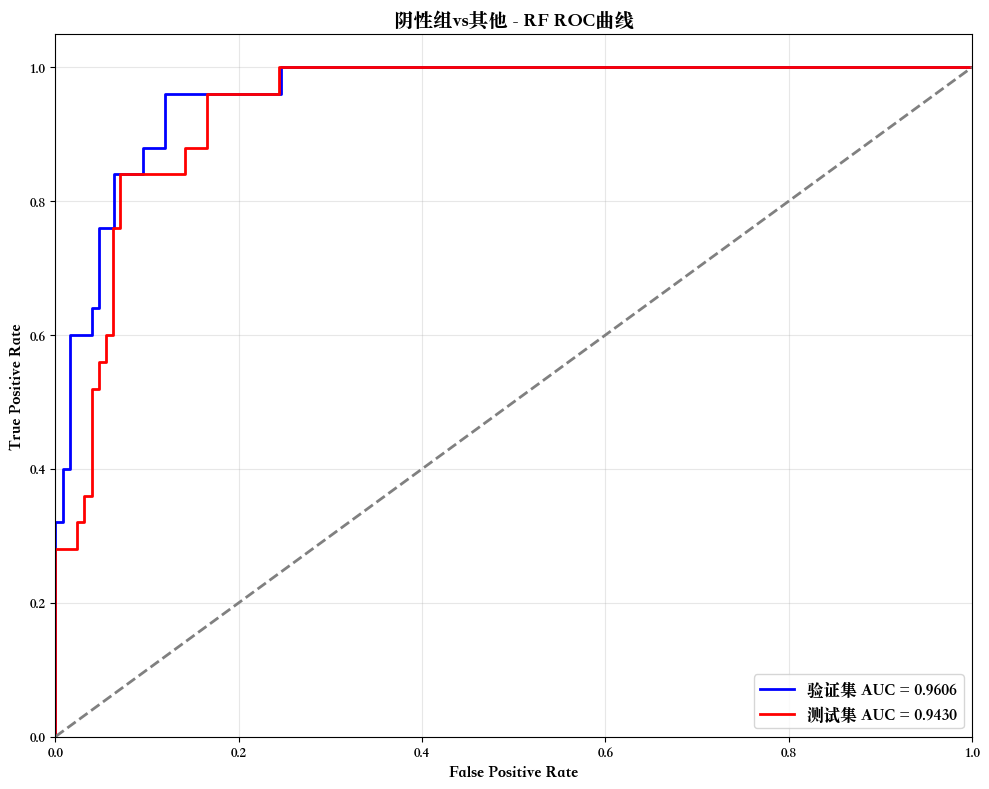


===== SHAP 特征重要性 (柱状图):  =====


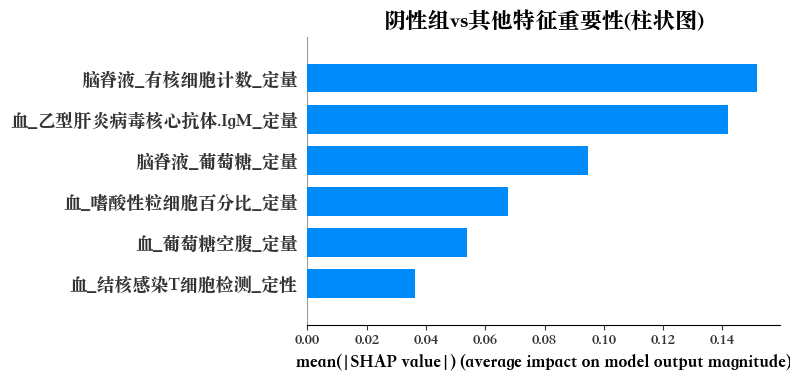


===== SHAP 特征分布 (蜂群图): =====


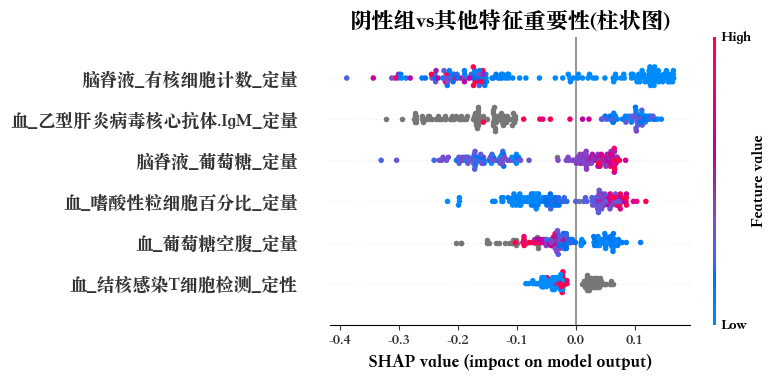

[I 2025-09-29 14:09:04,723] A new study created in memory with name: no-name-66cbb5f3-e570-48cc-8801-438ecfae8828


开始超参数优化...


Best trial: 0. Best value: 0.141054:   2%|▏         | 2/100 [00:00<00:07, 12.45it/s]

[I 2025-09-29 14:09:04,820] Trial 0 finished with value: 0.14105447276361827 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.14105447276361827.
[I 2025-09-29 14:09:04,883] Trial 1 finished with value: 0.17928535732133932 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.14105447276361827.


Best trial: 0. Best value: 0.141054:   4%|▍         | 4/100 [00:00<00:10,  9.25it/s]

...

[I 2025-09-29 14:09:27,735] Trial 97 finished with value: 0.13255872063968022 and parameters: {'n_estimators': 450, 'max_depth': 30, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 45 with value: 0.12731134432783608.


Best trial: 45. Best value: 0.127311:  99%|█████████▉| 99/100 [00:23<00:00,  4.41it/s]

[I 2025-09-29 14:09:27,976] Trial 98 finished with value: 0.13030984507746135 and parameters: {'n_estimators': 450, 'max_depth': 25, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 45 with value: 0.12731134432783608.


Best trial: 45. Best value: 0.127311: 100%|██████████| 100/100 [00:23<00:00,  4.26it/s]


[I 2025-09-29 14:09:28,186] Trial 99 finished with value: 0.13005997001499248 and parameters: {'n_estimators': 400, 'max_depth': 28, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 45 with value: 0.12731134432783608.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.8727
  Best params: 
    n_estimators: 450
    max_depth: 26
    min_samples_split: 3
    min_samples_leaf: 10
    max_features: None
    bootstrap: True
    criterion: entropy
    class_weight: balanced

使用最佳参数训练最终模型...
最佳阈值: 0.40，测试集最大auc: 0.8355

验证 集评估结果:
Accuracy: 0.8346
Precision: 0.8636
Recall: 0.8261
F1-Score: 0.8444
AUC: 0.8727
最佳阈值: 0.45，测试集最大auc: 0.8413

测试 集评估结果:
Accuracy: 0.8425
Precision: 0.8551
Recall: 0.8551
F1-Score: 0.8551
AUC: 0.8922


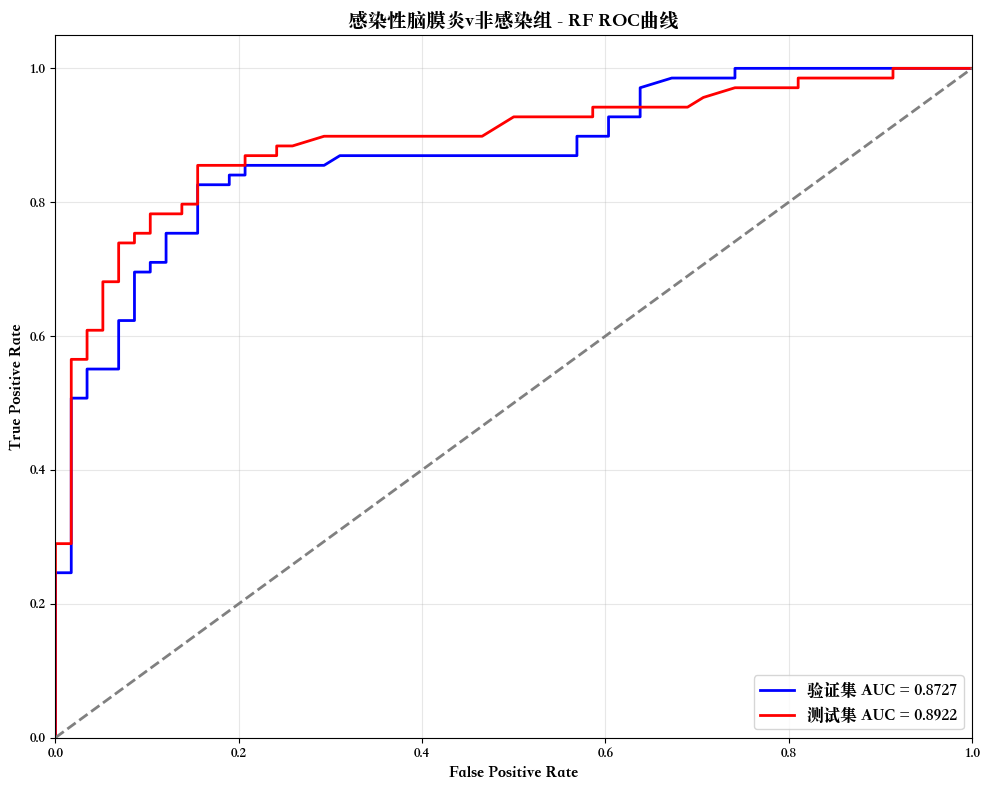


===== SHAP 特征重要性 (柱状图):  =====


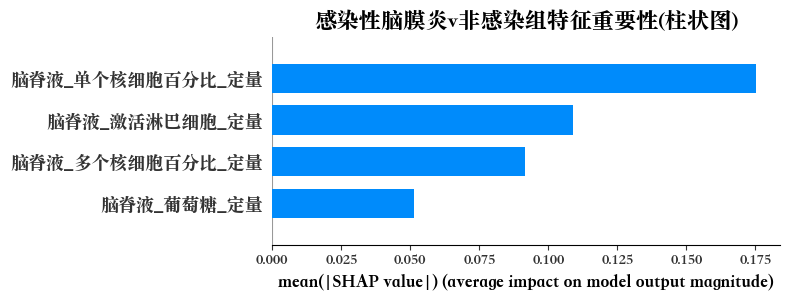


===== SHAP 特征分布 (蜂群图): =====


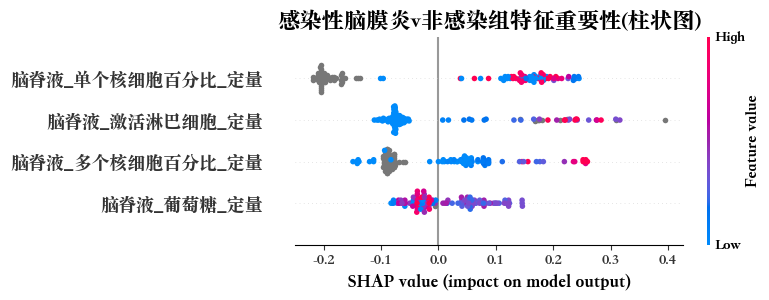

[I 2025-09-29 14:09:29,002] A new study created in memory with name: no-name-62e2a592-4339-4261-b1b3-cd905556f091


开始超参数优化...


Best trial: 0. Best value: 0.164835:   2%|▏         | 2/100 [00:00<00:07, 13.08it/s]

[I 2025-09-29 14:09:29,092] Trial 0 finished with value: 0.1648351648351648 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.1648351648351648.
[I 2025-09-29 14:09:29,155] Trial 1 finished with value: 0.30975274725274726 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.1648351648351648.


Best trial: 2. Best value: 0.144231:   4%|▍         | 4/100 [00:00<00:10,  9.26it/s]

...

[I 2025-09-29 14:09:38,917] Trial 94 finished with value: 0.11950549450549453 and parameters: {'n_estimators': 150, 'max_depth': 23, 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 79 with value: 0.11950549450549441.
[I 2025-09-29 14:09:39,006] Trial 95 finished with value: 0.12225274725274726 and parameters: {'n_estimators': 150, 'max_depth': 21, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 79 with value: 0.11950549450549441.


Best trial: 79. Best value: 0.119505:  99%|█████████▉| 99/100 [00:10<00:00, 11.50it/s]

[I 2025-09-29 14:09:39,123] Trial 96 finished with value: 0.12637362637362637 and parameters: {'n_estimators': 200, 'max_depth': 23, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 79 with value: 0.11950549450549441.
[I 2025-09-29 14:09:39,187] Trial 97 finished with value: 0.13186813186813184 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 79 with value: 0.11950549450549441.
[I 2025-09-29 14:09:39,281] Trial 98 finished with value: 0.14972527472527475 and parameters: {'n_estimators': 150, 'max_depth': 24, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 79 with value: 0.11950549450549441.


Best trial: 79. Best value: 0.119505: 100%|██████████| 100/100 [00:10<00:00,  9.64it/s]


[I 2025-09-29 14:09:39,380] Trial 99 finished with value: 0.1291208791208791 and parameters: {'n_estimators': 150, 'max_depth': 17, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 79 with value: 0.11950549450549441.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.8805
  Best params: 
    n_estimators: 150
    max_depth: 21
    min_samples_split: 12
    min_samples_leaf: 2
    max_features: log2
    bootstrap: True
    criterion: entropy
    class_weight: balanced_subsample

使用最佳参数训练最终模型...
最佳阈值: 0.25，测试集最大auc: 0.8070

验证 集评估结果:
Accuracy: 0.7826
Precision: 0.4583
Recall: 0.8462
F1-Score: 0.5946
AUC: 0.8805
最佳阈值: 0.35，测试集最大auc: 0.8606

测试 集评估结果:
Accuracy: 0.8696
Precision: 0.6111
Recall: 0.8462
F1-Score: 0.7097
AUC: 0.8777


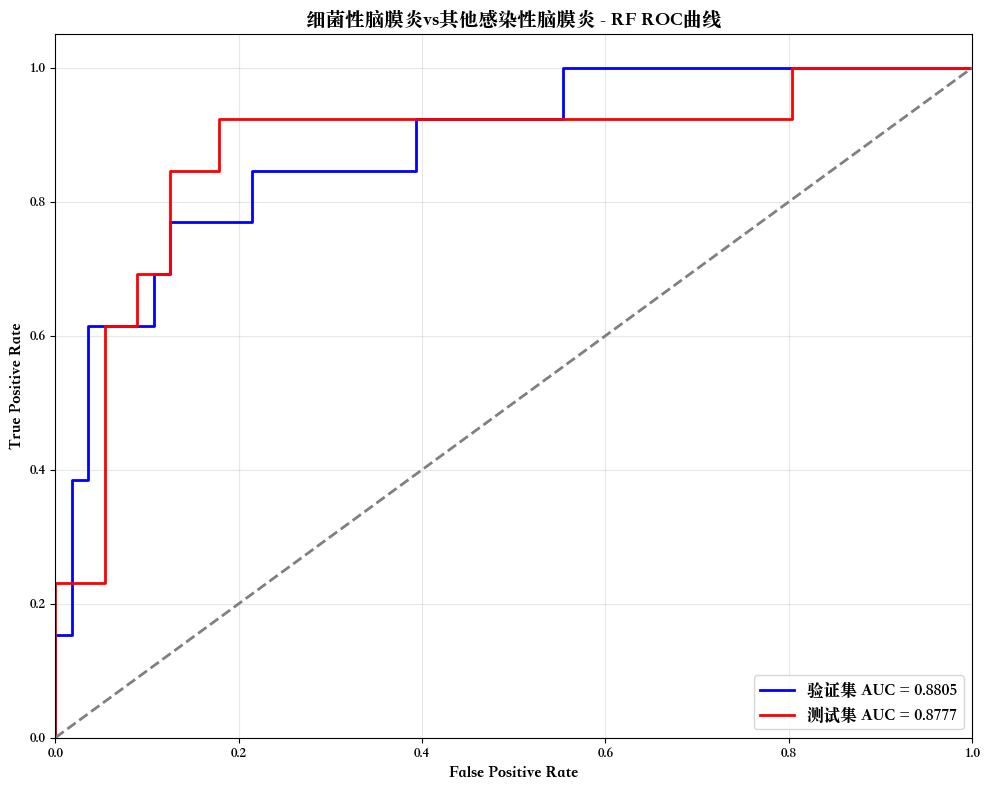


===== SHAP 特征重要性 (柱状图):  =====


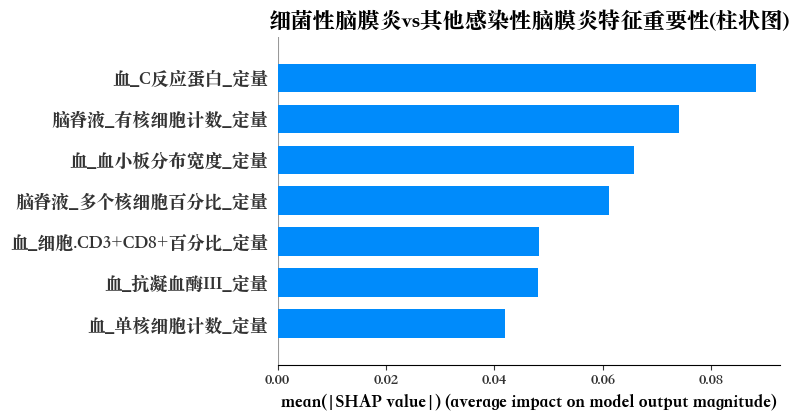


===== SHAP 特征分布 (蜂群图): =====


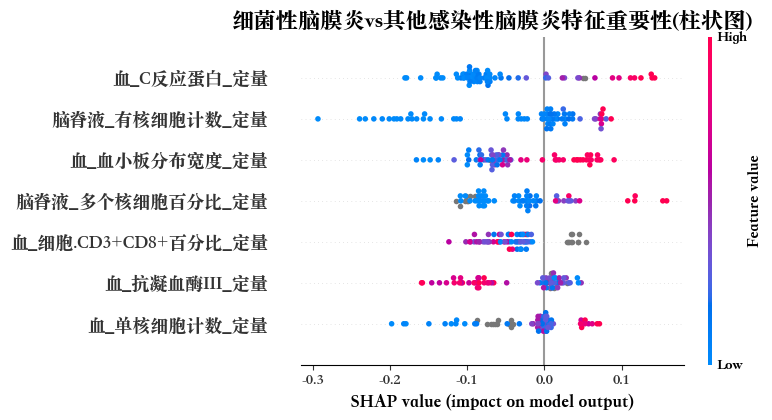

[I 2025-09-29 14:09:40,026] A new study created in memory with name: no-name-3ec9f870-b3ef-477a-be8e-80de910cb1f9


开始超参数优化...


Best trial: 0. Best value: 0.110436:   2%|▏         | 2/100 [00:00<00:07, 12.46it/s]

[I 2025-09-29 14:09:40,114] Trial 0 finished with value: 0.11043566362715307 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.11043566362715307.
[I 2025-09-29 14:09:40,186] Trial 1 finished with value: 0.3029381965552178 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.11043566362715307.


Best trial: 4. Best value: 0.10537:   4%|▍         | 4/100 [00:00<00:10,  9.28it/s] 

...

[I 2025-09-29 14:09:56,841] Trial 95 finished with value: 0.10030395136778114 and parameters: {'n_estimators': 450, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 63 with value: 0.08814589665653494.
[I 2025-09-29 14:09:56,968] Trial 96 finished with value: 0.11651469098277611 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 63 with value: 0.08814589665653494.


Best trial: 63. Best value: 0.0881459:  98%|█████████▊| 98/100 [00:17<00:00,  4.66it/s]

[I 2025-09-29 14:09:57,226] Trial 97 finished with value: 0.11043566362715307 and parameters: {'n_estimators': 450, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}. Best is trial 63 with value: 0.08814589665653494.
[I 2025-09-29 14:09:57,323] Trial 98 finished with value: 0.11043566362715307 and parameters: {'n_estimators': 200, 'max_depth': 17, 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 63 with value: 0.08814589665653494.


Best trial: 63. Best value: 0.0881459: 100%|██████████| 100/100 [00:17<00:00,  5.71it/s]


[I 2025-09-29 14:09:57,537] Trial 99 finished with value: 0.09625126646403237 and parameters: {'n_estimators': 450, 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 63 with value: 0.08814589665653494.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9119
  Best params: 
    n_estimators: 450
    max_depth: 23
    min_samples_split: 6
    min_samples_leaf: 4
    max_features: log2
    bootstrap: True
    criterion: gini
    class_weight: balanced

使用最佳参数训练最终模型...
最佳阈值: 0.35，测试集最大auc: 0.8830

验证 集评估结果:
Accuracy: 0.8382
Precision: 0.6562
Recall: 1.0000
F1-Score: 0.7925
AUC: 0.9119
最佳阈值: 0.30，测试集最大auc: 0.7112

测试 集评估结果:
Accuracy: 0.6714
Precision: 0.4865
Recall: 0.8182
F1-Score: 0.6102
AUC: 0.7841


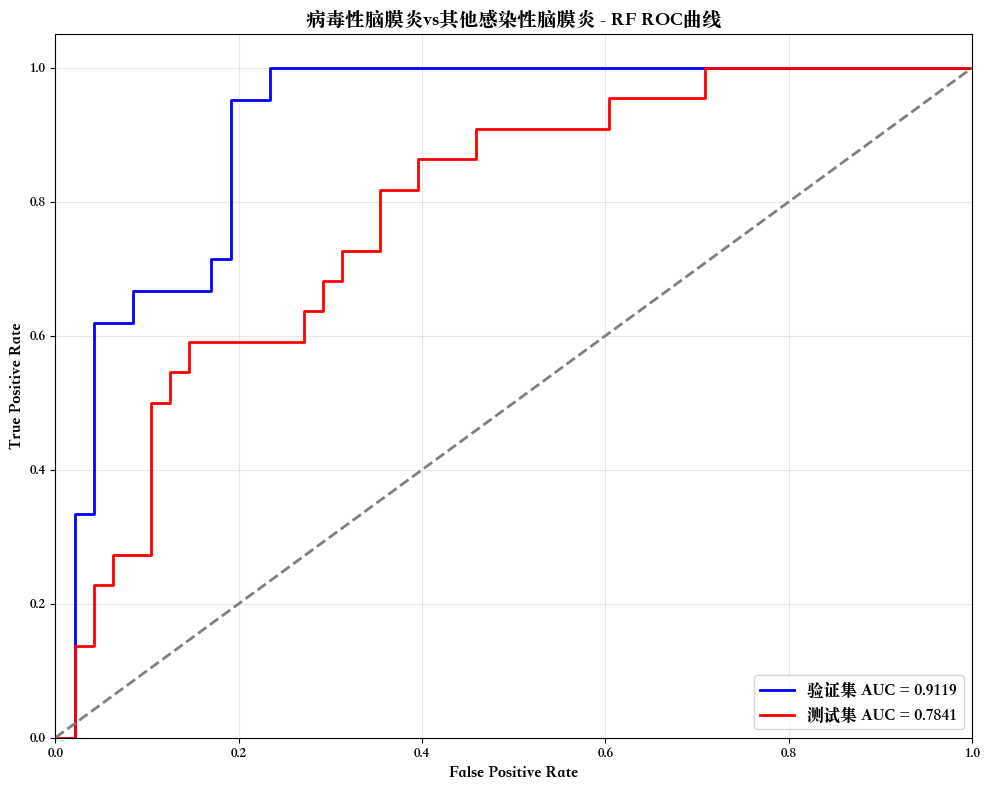


===== SHAP 特征重要性 (柱状图):  =====


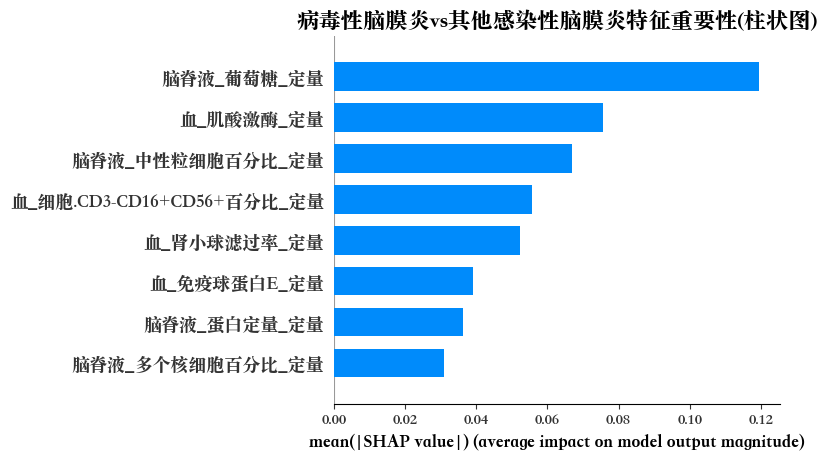


===== SHAP 特征分布 (蜂群图): =====


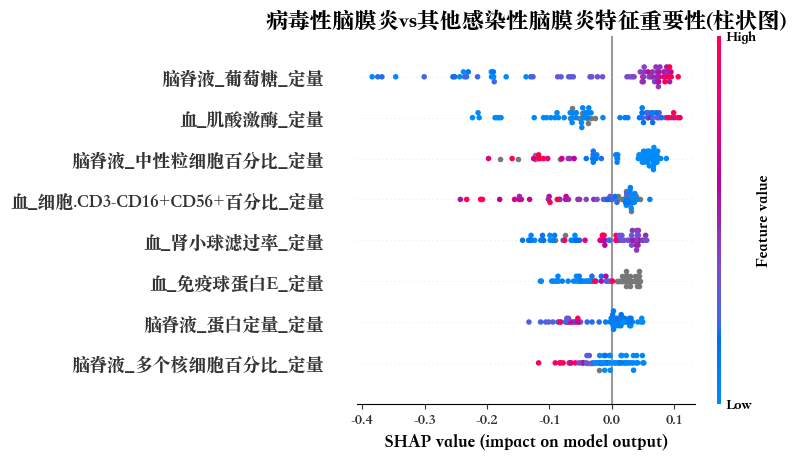

[I 2025-09-29 14:09:58,376] A new study created in memory with name: no-name-fb0f73d8-5388-44c0-8087-52842cc6be24


开始超参数优化...


Best trial: 1. Best value: 0.0840774:   2%|▏         | 2/100 [00:00<00:07, 13.91it/s]

[I 2025-09-29 14:09:58,461] Trial 0 finished with value: 0.15476190476190477 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.15476190476190477.
[I 2025-09-29 14:09:58,519] Trial 1 finished with value: 0.08407738095238093 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 1 with value: 0.08407738095238093.


Best trial: 1. Best value: 0.0840774:   4%|▍         | 4/100 [00:00<00:09, 10.12it/s]

...

[I 2025-09-29 14:10:17,803] Trial 97 finished with value: 0.12351190476190466 and parameters: {'n_estimators': 400, 'max_depth': 18, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True, 'criterion': 'entropy', 'class_weight': None}. Best is trial 23 with value: 0.06696428571428559.


Best trial: 23. Best value: 0.0669643:  99%|█████████▉| 99/100 [00:19<00:00,  3.88it/s]

[I 2025-09-29 14:10:18,049] Trial 98 finished with value: 0.0848214285714286 and parameters: {'n_estimators': 450, 'max_depth': 15, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 23 with value: 0.06696428571428559.


Best trial: 23. Best value: 0.0669643: 100%|██████████| 100/100 [00:19<00:00,  5.03it/s]


[I 2025-09-29 14:10:18,270] Trial 99 finished with value: 0.2946428571428571 and parameters: {'n_estimators': 400, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 23 with value: 0.06696428571428559.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9330
  Best params: 
    n_estimators: 300
    max_depth: 18
    min_samples_split: 12
    min_samples_leaf: 8
    max_features: None
    bootstrap: False
    criterion: entropy
    class_weight: None

使用最佳参数训练最终模型...
最佳阈值: 0.25，测试集最大auc: 0.9405

验证 集评估结果:
Accuracy: 0.9559
Precision: 0.8462
Recall: 0.9167
F1-Score: 0.8800
AUC: 0.9330
最佳阈值: 0.10，测试集最大auc: 0.7497

测试 集评估结果:
Accuracy: 0.7857
Precision: 0.4500
Recall: 0.6923
F1-Score: 0.5455
AUC: 0.8043


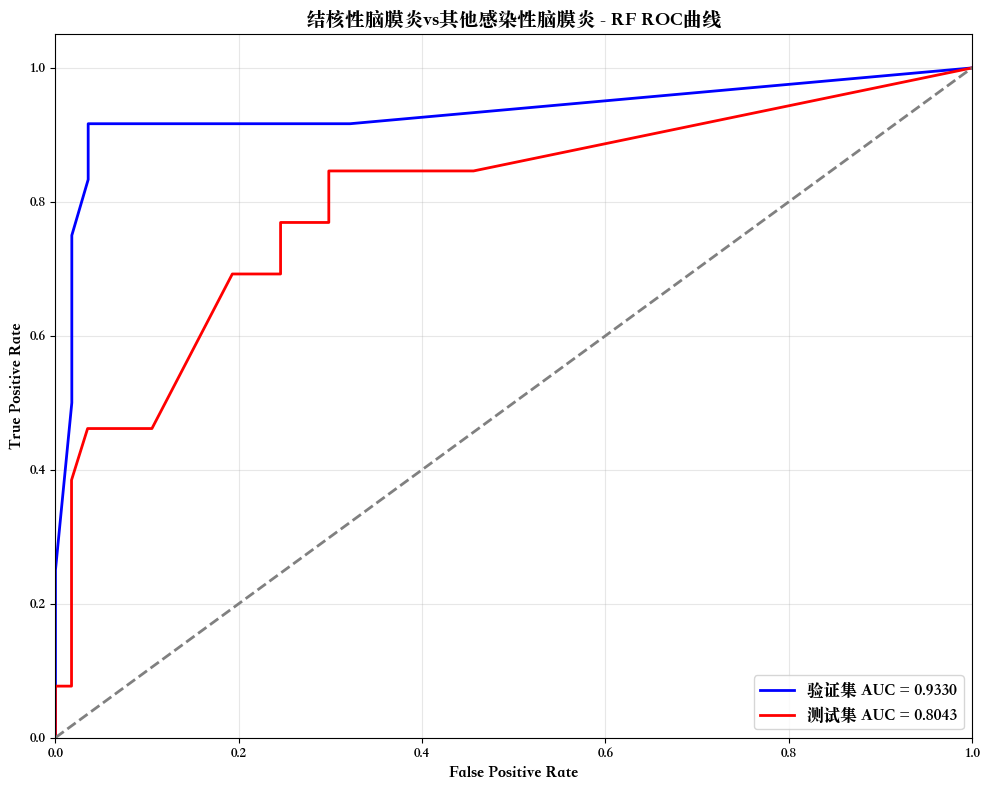


===== SHAP 特征重要性 (柱状图):  =====


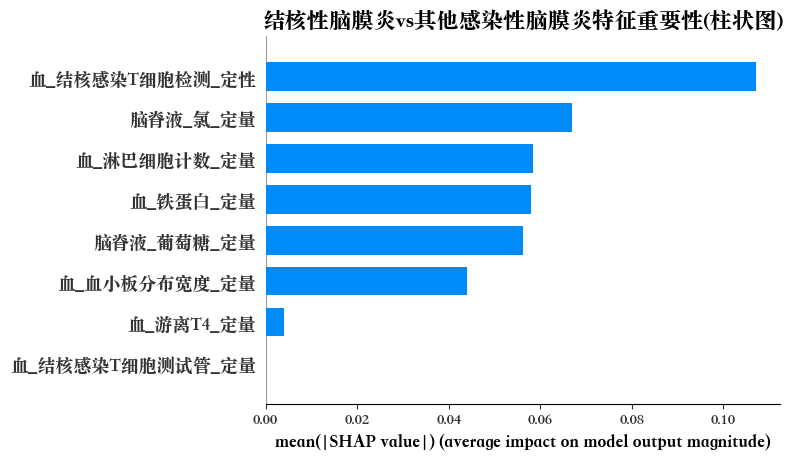


===== SHAP 特征分布 (蜂群图): =====


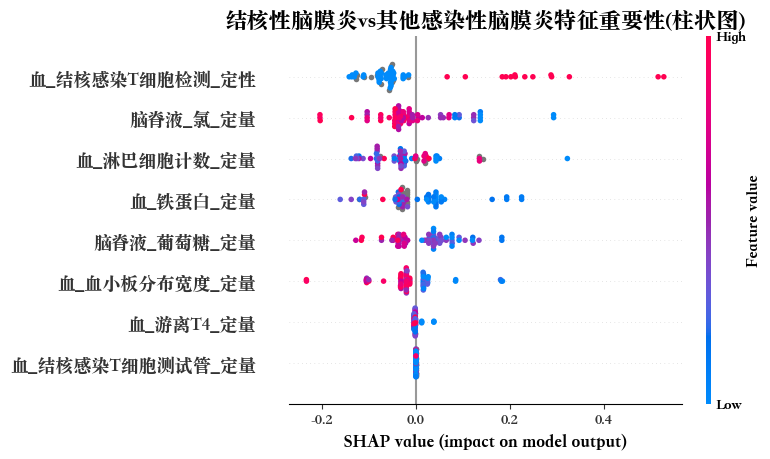

[I 2025-09-29 14:10:18,990] A new study created in memory with name: no-name-2a5d22c0-7e89-4316-acb8-d3c933f1f613


开始超参数优化...


Best trial: 0. Best value: 0.202128:   2%|▏         | 2/100 [00:00<00:05, 16.56it/s]

[I 2025-09-29 14:10:19,070] Trial 0 finished with value: 0.2021276595744681 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.2021276595744681.
[I 2025-09-29 14:10:19,111] Trial 1 finished with value: 0.20938104448742745 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.2021276595744681.


Best trial: 2. Best value: 0.198259:   5%|▌         | 5/100 [00:00<00:07, 12.43it/s]

...

[I 2025-09-29 14:10:25,379] Trial 92 finished with value: 0.16005802707930372 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 28 with value: 0.1581237911025145.
[I 2025-09-29 14:10:25,477] Trial 93 finished with value: 0.16005802707930372 and parameters: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 28 with value: 0.1581237911025145.
[I 2025-09-29 14:10:25,548] Trial 94 finished with value: 0.1731141199226306 and parameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 28 with value: 0.1581237911025145.


Best trial: 28. Best value: 0.158124:  98%|█████████▊| 98/100 [00:06<00:00, 11.81it/s]

[I 2025-09-29 14:10:25,632] Trial 95 finished with value: 0.16537717601547386 and parameters: {'n_estimators': 250, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 28 with value: 0.1581237911025145.
[I 2025-09-29 14:10:25,739] Trial 96 finished with value: 0.17746615087040618 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 28 with value: 0.1581237911025145.
[I 2025-09-29 14:10:25,823] Trial 97 finished with value: 0.17601547388781424 and parameters: {'n_estimators': 250, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 28 with value: 0.1581237911025145.


Best trial: 28. Best value: 0.158124: 100%|██████████| 100/100 [00:06<00:00, 14.29it/s]


[I 2025-09-29 14:10:25,901] Trial 98 finished with value: 0.1895551257253385 and parameters: {'n_estimators': 200, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': False, 'criterion': 'gini', 'class_weight': None}. Best is trial 28 with value: 0.1581237911025145.
[I 2025-09-29 14:10:25,988] Trial 99 finished with value: 0.17214700193423604 and parameters: {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 28 with value: 0.1581237911025145.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.8419
  Best params: 
    n_estimators: 100
    max_depth: 26
    min_samples_split: 10
    min_samples_leaf: 8
    max_features: log2
    bootstrap: False
    criterion: entropy
    class_weight: None

使用最佳参数训练最终模型...
最佳阈值: 0.30，测试集最大auc: 0.7722

验证 集评估结果:
Accuracy: 0.7391
Precision: 0.5588
Re

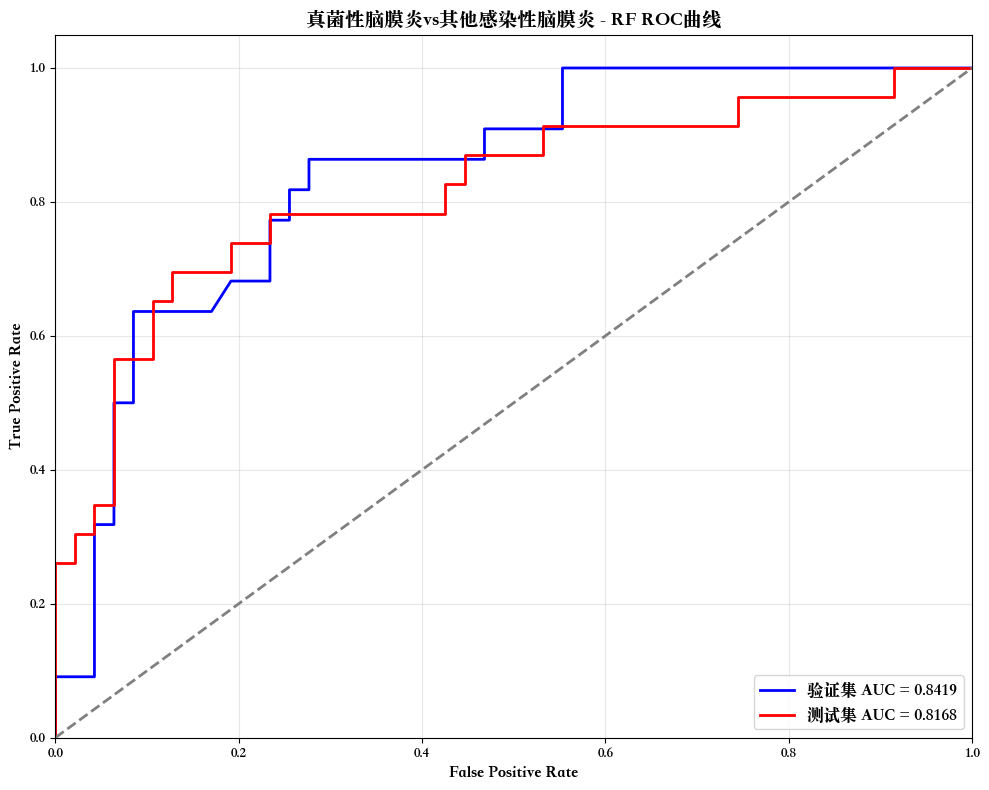


===== SHAP 特征重要性 (柱状图):  =====


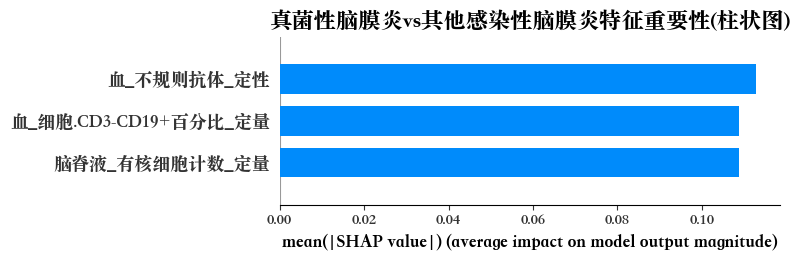


===== SHAP 特征分布 (蜂群图): =====


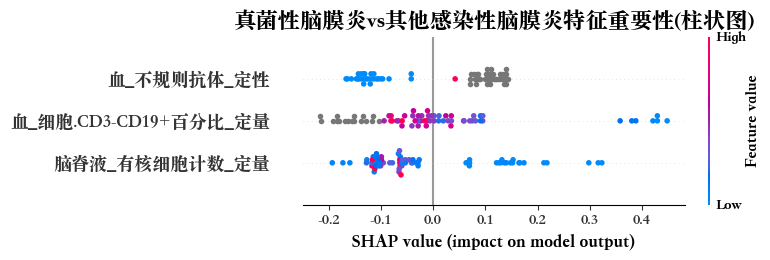

[I 2025-09-29 14:10:26,468] A new study created in memory with name: no-name-857032e3-ec3f-48e3-8236-1f304d2337b4


开始超参数优化...


Best trial: 0. Best value: 0.068306:   1%|          | 1/100 [00:00<00:10,  9.76it/s]

[I 2025-09-29 14:10:26,570] Trial 0 finished with value: 0.06830601092896171 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.06830601092896171.
[I 2025-09-29 14:10:26,653] Trial 1 finished with value: 0.14453551912568297 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.06830601092896171.


Best trial: 0. Best value: 0.068306:   4%|▍         | 4/100 [00:00<00:13,  6.90it/s]

...

[I 2025-09-29 14:10:45,788] Trial 97 finished with value: 0.060109289617486406 and parameters: {'n_estimators': 450, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 84 with value: 0.058743169398907114.


Best trial: 84. Best value: 0.0587432:  99%|█████████▉| 99/100 [00:19<00:00,  4.13it/s]

[I 2025-09-29 14:10:46,029] Trial 98 finished with value: 0.060109289617486406 and parameters: {'n_estimators': 450, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 84 with value: 0.058743169398907114.


Best trial: 99. Best value: 0.0584699: 100%|██████████| 100/100 [00:19<00:00,  5.04it/s]


[I 2025-09-29 14:10:46,289] Trial 99 finished with value: 0.05846994535519123 and parameters: {'n_estimators': 500, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 99 with value: 0.05846994535519123.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9415
  Best params: 
    n_estimators: 500
    max_depth: 12
    min_samples_split: 4
    min_samples_leaf: 7
    max_features: sqrt
    bootstrap: True
    criterion: entropy
    class_weight: balanced

使用最佳参数训练最终模型...
最佳阈值: 0.45，测试集最大auc: 0.8844

验证 集评估结果:
Accuracy: 0.8750
Precision: 0.6279
Recall: 0.9000
F1-Score: 0.7397
AUC: 0.9415
最佳阈值: 0.35，测试集最大auc: 0.8178

测试 集评估结果:
Accuracy: 0.8487
Precision: 0.5897
Recall: 0.7667
F1-Score: 0.6667
AUC: 0.8530


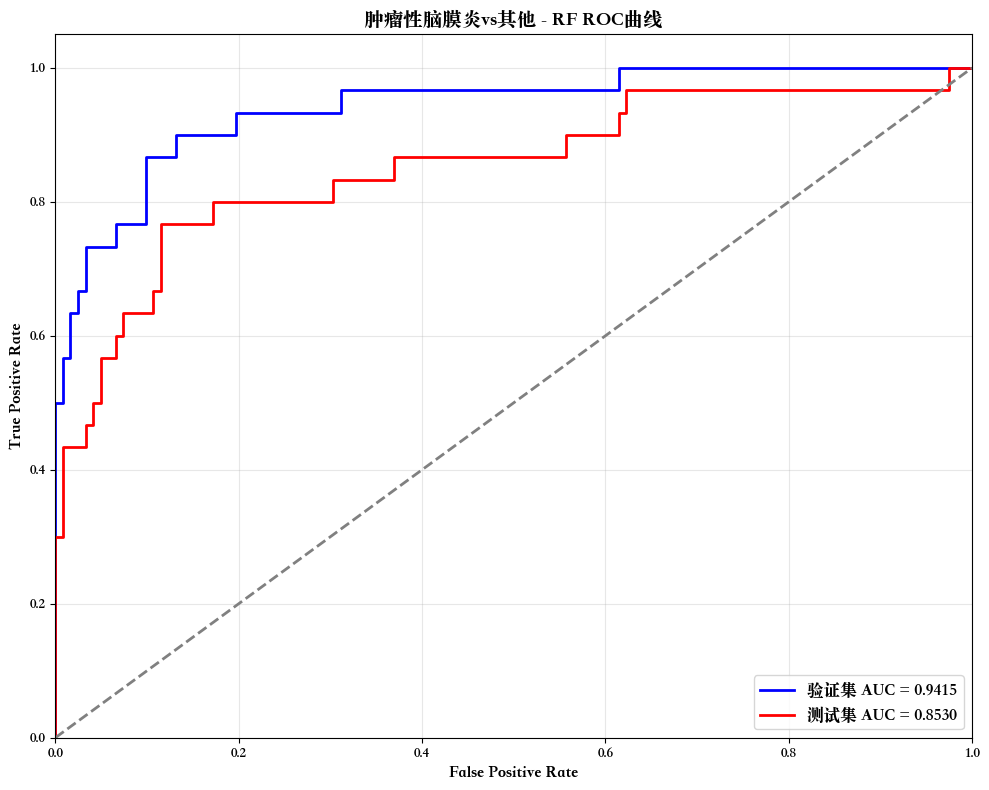


===== SHAP 特征重要性 (柱状图):  =====


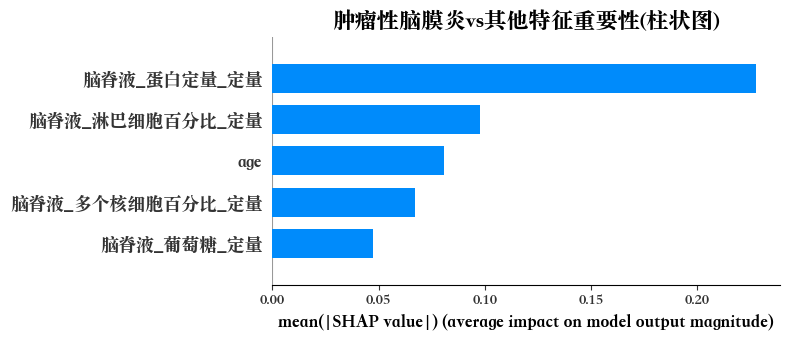


===== SHAP 特征分布 (蜂群图): =====


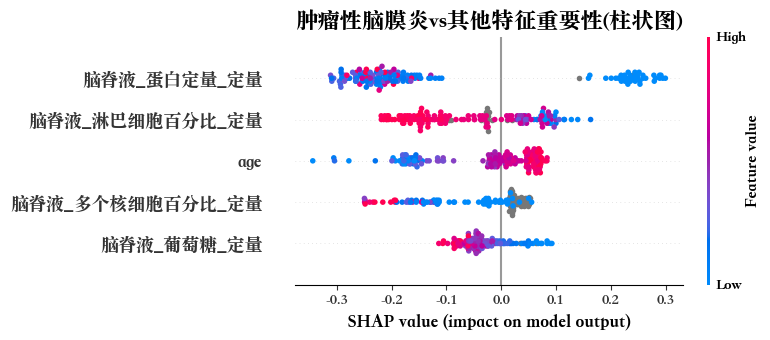

[I 2025-09-29 14:10:47,627] A new study created in memory with name: no-name-7a0e3ff7-1f65-405f-8e34-19684bd79495


开始超参数优化...


Best trial: 0. Best value: 0.178281:   2%|▏         | 2/100 [00:00<00:32,  3.05it/s]

[I 2025-09-29 14:10:48,266] Trial 0 finished with value: 0.17828106852497094 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.17828106852497094.
[I 2025-09-29 14:10:48,378] Trial 1 finished with value: 0.2610336817653891 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.17828106852497094.


Best trial: 0. Best value: 0.178281:   5%|▌         | 5/100 [00:01<00:15,  6.14it/s]

...

[I 2025-09-29 14:11:05,207] Trial 95 finished with value: 0.17102206736353076 and parameters: {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 52 with value: 0.16085946573751442.


Best trial: 52. Best value: 0.160859:  98%|█████████▊| 98/100 [00:18<00:00,  4.91it/s]

[I 2025-09-29 14:11:05,544] Trial 96 finished with value: 0.33275261324041816 and parameters: {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 52 with value: 0.16085946573751442.
[I 2025-09-29 14:11:05,720] Trial 97 finished with value: 0.16986062717770034 and parameters: {'n_estimators': 300, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': None}. Best is trial 52 with value: 0.16085946573751442.


Best trial: 52. Best value: 0.160859: 100%|██████████| 100/100 [00:18<00:00,  5.44it/s]


[I 2025-09-29 14:11:05,885] Trial 98 finished with value: 0.17131242740998842 and parameters: {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 52 with value: 0.16085946573751442.
[I 2025-09-29 14:11:06,018] Trial 99 finished with value: 0.1686991869918698 and parameters: {'n_estimators': 250, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 52 with value: 0.16085946573751442.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.8391
  Best params: 
    n_estimators: 300
    max_depth: 22
    min_samples_split: 7
    min_samples_leaf: 4
    max_features: sqrt
    bootstrap: True
    criterion: entropy
    class_weight: balanced

使用最佳参数训练最终模型...
最佳阈值: 0.35，测试集最大auc: 0.7661

验证 集评估结果:
Accuracy: 0.8212
Precisio

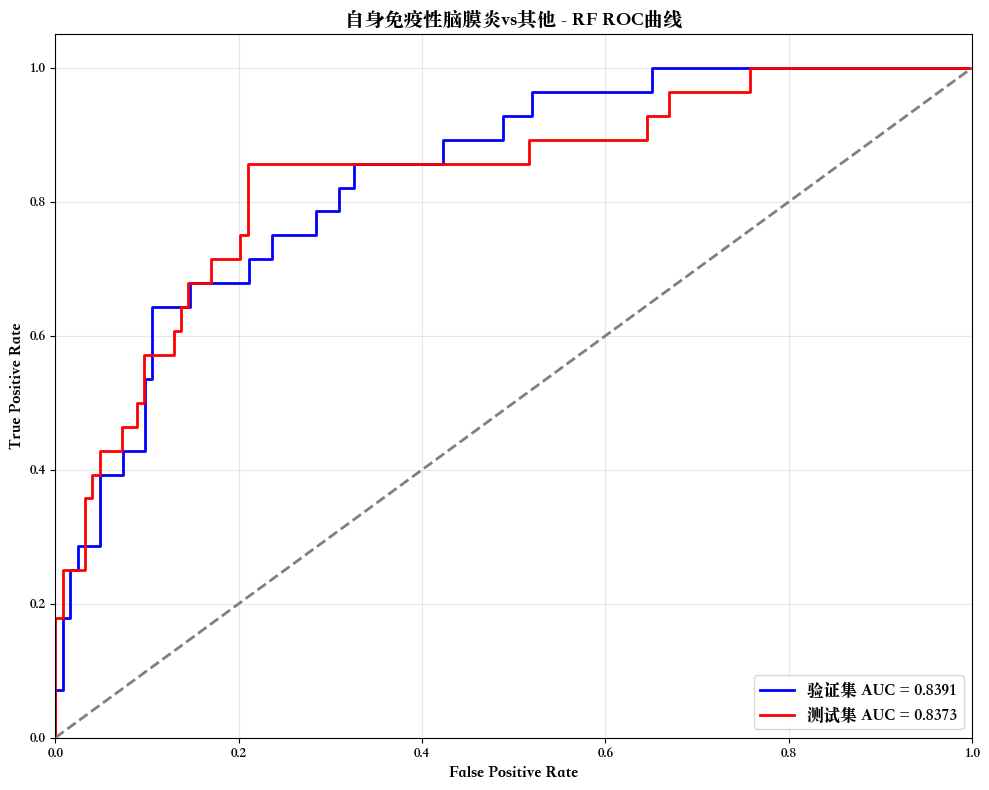


===== SHAP 特征重要性 (柱状图):  =====


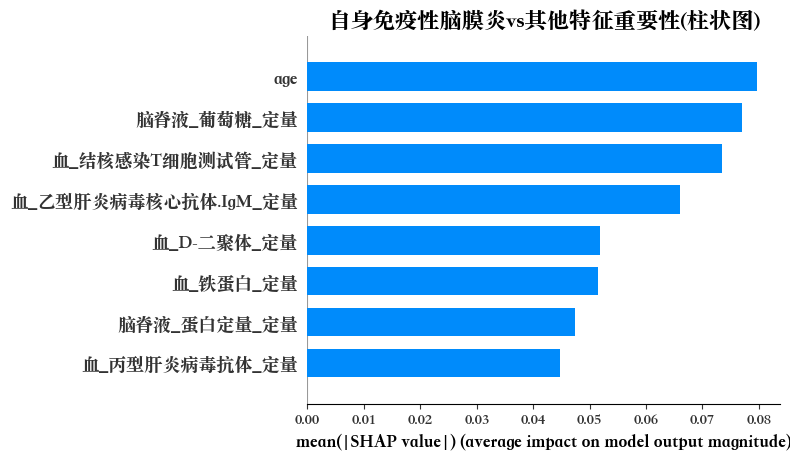


===== SHAP 特征分布 (蜂群图): =====


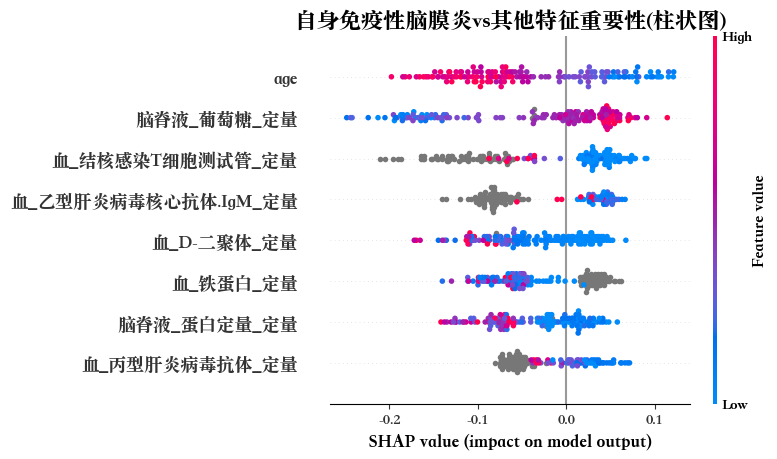

[I 2025-09-29 14:11:06,823] A new study created in memory with name: no-name-bc6d2258-2771-419f-bb27-ccb2f95961c8


开始超参数优化...


Best trial: 0. Best value: 0.210623:   2%|▏         | 2/100 [00:00<00:06, 15.28it/s]

[I 2025-09-29 14:11:06,905] Trial 0 finished with value: 0.21062271062271065 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.21062271062271065.
[I 2025-09-29 14:11:06,954] Trial 1 finished with value: 0.24450549450549453 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.21062271062271065.


Best trial: 4. Best value: 0.188645:   4%|▍         | 4/100 [00:00<00:08, 11.17it/s]

...

[I 2025-09-29 14:11:23,122] Trial 95 finished with value: 0.17032967032967028 and parameters: {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 88 with value: 0.17032967032967028.
[I 2025-09-29 14:11:23,265] Trial 96 finished with value: 0.2216117216117216 and parameters: {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': False, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 88 with value: 0.17032967032967028.


Best trial: 88. Best value: 0.17033:  99%|█████████▉| 99/100 [00:16<00:00,  6.59it/s]

[I 2025-09-29 14:11:23,396] Trial 97 finished with value: 0.1923076923076923 and parameters: {'n_estimators': 250, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 88 with value: 0.17032967032967028.
[I 2025-09-29 14:11:23,556] Trial 98 finished with value: 0.17032967032967028 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 88 with value: 0.17032967032967028.


Best trial: 88. Best value: 0.17033: 100%|██████████| 100/100 [00:16<00:00,  5.92it/s]


[I 2025-09-29 14:11:23,716] Trial 99 finished with value: 0.17032967032967028 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 88 with value: 0.17032967032967028.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.8297
  Best params: 
    n_estimators: 300
    max_depth: 12
    min_samples_split: 10
    min_samples_leaf: 10
    max_features: log2
    bootstrap: True
    criterion: entropy
    class_weight: balanced_subsample

使用最佳参数训练最终模型...
最佳阈值: 0.45，测试集最大auc: 0.7848

验证 集评估结果:
Accuracy: 0.7872
Precision: 0.7619
Recall: 0.7619
F1-Score: 0.7619
AUC: 0.8297
最佳阈值: 0.45，测试集最大auc: 0.7567

测试 集评估结果:
Accuracy: 0.7551
Precision: 0.7083
Recall: 0.7727
F1-Score: 0.7391
AUC: 0.8350


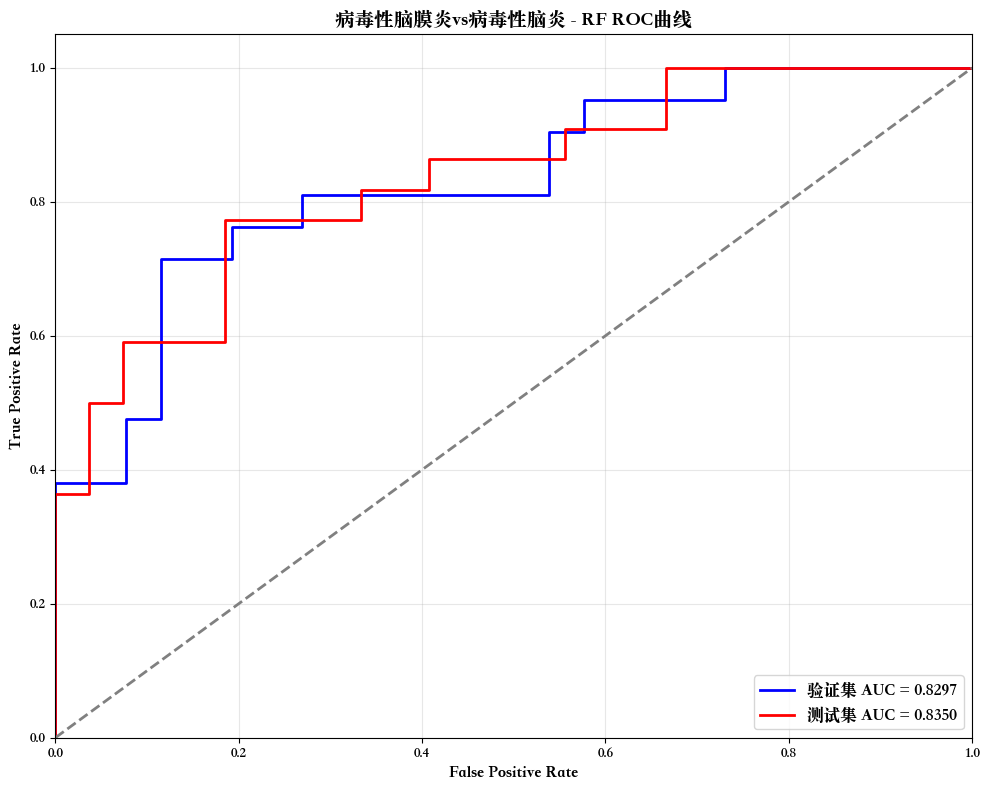


===== SHAP 特征重要性 (柱状图):  =====


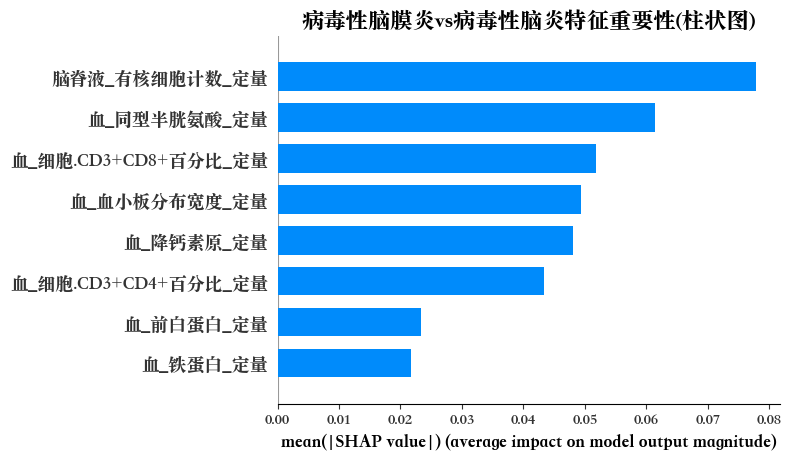


===== SHAP 特征分布 (蜂群图): =====


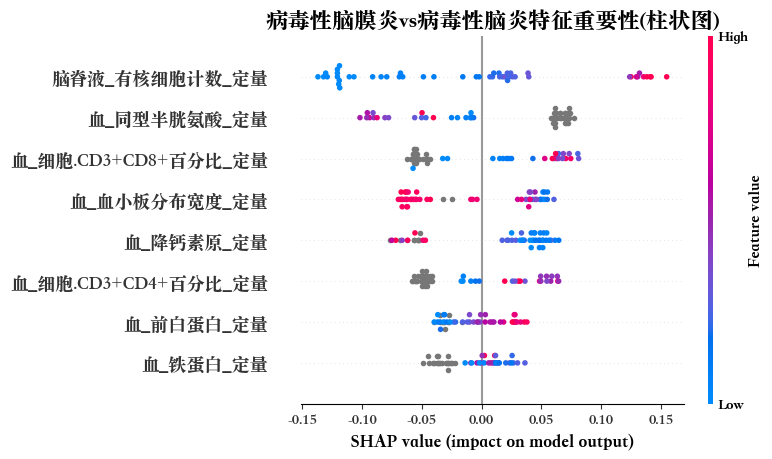

In [ ]:
filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df, current_dataset):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    # 得到最优模型
    result = train(X_train, y_train, X_val, y_val)
    final_model = result[0]
    # 评估验证集和测试集
    val_results = evaluate_model(final_model, X_val, y_val, "验证")
    test_results = evaluate_model(final_model, X_test, y_test, "测试")    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)

    # 绘制shap图
    draw_shap(final_model, X_train, X_test, current_dataset, key)
    return result[1]

if extract_integers(data_path)[-1] == 2:
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎v非感染组': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    result_para = run_model(key, item, filtered_df2, current_dataset)

     # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)


In [139]:
result_para

{'n_estimators': 50,
 'max_depth': 7,
 'min_samples_split': 11,
 'min_samples_leaf': 3,
 'max_features': 'log2',
 'bootstrap': True,
 'criterion': 'entropy',
 'class_weight': None,
 'random_state': 42,
 'oob_score': True}

In [137]:

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})
# filtered_df = filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']]
screen_data = {
    # '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    # '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    # '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    # '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    # '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    # '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    # '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    # '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

item = []
for key, item1 in screen_data.items():
    item = item1
print(item)

selected_df = filtered_df[filtered_df['分组'].isin(item[0])]

# 选择特征 将数据正例和反例平均分配
filter_1 = selected_df[selected_df["分组"].isin(item[1])]
filter_2 = selected_df[selected_df["分组"].isin(item[2])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]
# print(X_1.columns)
# 标签（分组，1 类与其他类）
y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
y_2 = (filter_2['分组'].isin(item[1])).astype(int) 


# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])




[[0, 1, 2, 3, 4, 5, 6], [5], [0, 1, 2, 3, 4, 6]]


最佳阈值: 0.15，测试集最大auc: 0.8757


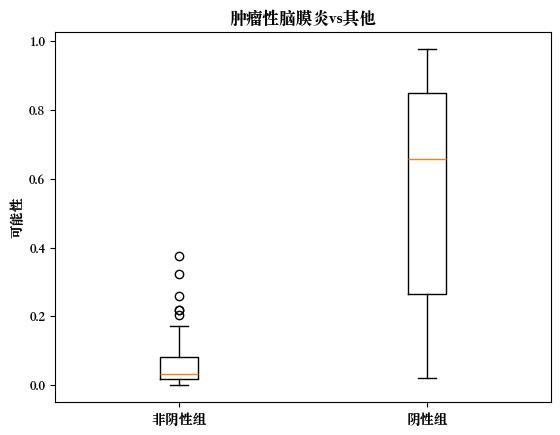


测试 集评估结果:
Accuracy: 0.9276
Precision: 1.0000
Recall: 0.6333
F1-Score: 0.7755
AUC: 0.9238
最佳阈值: 0.40，测试集最大auc: 0.9167

验证 集评估结果:
Accuracy: 0.9605
Precision: 1.0000
Recall: 0.8000
F1-Score: 0.8889
AUC: 0.9730
最佳阈值: 0.20，测试集最大auc: 0.9649

训练 集评估结果:
Accuracy: 0.9690
Precision: 1.0000
Recall: 0.8409
F1-Score: 0.9136
AUC: 0.9963
OOB AUC Score: 0.9338942307692306
Test AUC Score: 0.9237704918032787
Val AUC Score: 0.9729508196721312
Train AUC Score: 0.9963161838161838


In [140]:

# result_para['n_estimators'] = 250
result_para['oob_score'] = True
result_para['bootstrap'] = True

# result_para['use_label_encoder'] = False
# result_para['eval_metric'] = 'logloss'
# result_para['random_state'] = 42
# params = {
#     'n_estimators': 500,
#     'max_depth': 3,
#     'learning_rate': 0.014423244028784152,
#     'subsample': 0.9003002169351246,
#     'colsample_bytree': 0.8158764226043772,
#     'reg_alpha': 0.043594962064358575,
#     'reg_lambda':  0.4046273356274994,
#     'min_child_weight': 2,
#     'gamma': 0.24895493093075793,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }


model = RandomForestClassifier(**result_para)


model.fit(X_train, y_train)
# print("OOB Score:", model.oob_score_) 
oob_auc = roc_auc_score(y_train, model.oob_decision_function_[:, 1])
test_results = evaluate_model(model, X_test, y_test, "测试")
val_results = evaluate_model(model, X_val, y_val, "验证")
train_results = evaluate_model(model, X_train, y_train, "训练")
print("OOB AUC Score:", oob_auc) 
print("Test AUC Score:", test_results['auc'])
print("Val AUC Score:", val_results['auc'])
print("Train AUC Score:", train_results['auc'])
# evals_result = {}
# 训练模型
# model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)],  # 加入验证集
#     # eval_metric="logloss",
#     verbose=False,
#     # evals_result=evals_result
# )
# evals_result = model.evals_result()

# train_logloss = evals_result['validation_0']['logloss']
# val_logloss = evals_result['validation_1']['logloss']

# test_results = evaluate_model(model, X_test, y_test, "测试", "阴性组")    
# # print(test_results['auc'])
# # 绘制曲线
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, len(train_logloss) + 1), train_logloss, label='Train Logloss')
# plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='Validation Logloss')
# plt.xlabel('轮数')
# plt.ylabel('损失')
# plt.title(f'{list(screen_data.keys())[0]}损失曲线（拟合情况）')
# plt.legend()
# plt.show()

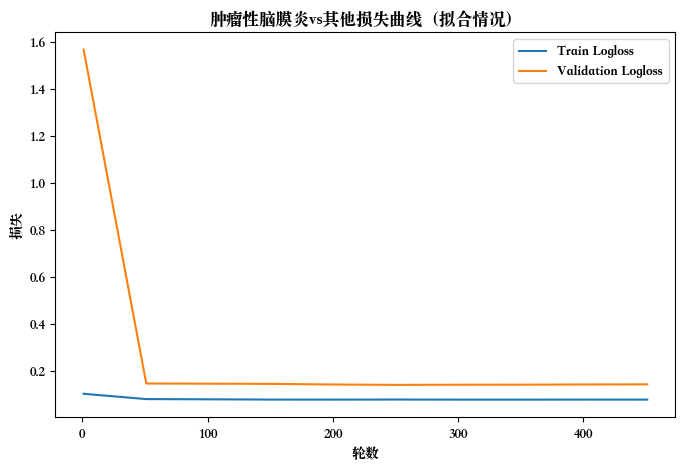

In [119]:
from sklearn.metrics import log_loss

train_losses = []
val_losses = []
n_estimators_range = range(1, 500, 50)  # 每隔10棵树观察一次
result_para

for n in n_estimators_range:
    result_para['n_estimators'] = n
    model = RandomForestClassifier(**result_para)
    model.fit(X_train, y_train)

    # 预测概率，算 logloss
    y_train_pred = model.predict_proba(X_train)
    y_val_pred = model.predict_proba(X_val)

    train_losses.append(log_loss(y_train, y_train_pred))
    val_losses.append(log_loss(y_val, y_val_pred))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, train_losses, label='Train Logloss')
plt.plot(n_estimators_range, val_losses, label='Validation Logloss')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.title(f'{list(screen_data.keys())[0]}损失曲线（拟合情况）')
plt.legend()
plt.show()
